# **Import Library and Load Dataset**

In [ ]:
!pip uninstall -y torch torchtext torchvision torchaudio && pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install torchtext --no-cache-dir
!pip install einops -q

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 127.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 110.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 131.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.

In [ ]:
import pandas as pd
import sklearn as sk
import scipy as sp
import matplotlib.pyplot as plt
import platform
import sys
from typing import Callable
import time
import random
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install wandb
import pickle

from PIL import Image
from einops import rearrange, reduce, repeat
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence
import torchtext
import os

print(f"The currently running torchtext version is: {torchtext.__version__}")


The currently running torchtext version is: 0.18.0+cpu


/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
IMG_SHAPE = [50, 200, 1]
#EMBEDDING_DIM = 256
EMBEDDING_DIM = 128
#max_seq_length = 152
n = 50000
#max_seq_len_1 = max_seq_length - 1

#**PREPROCESSING DATA**

In [ ]:
import kagglehub

# Download latest version
root_dir = kagglehub.dataset_download("shahrukhkhan/im2latex100k")
# path = kagglehub.dataset_download("gregoryeritsyan/im2latex-230k")

print("Path to dataset files:", root_dir)

KeyboardInterrupt: 

In [ ]:
preprocess_pipeline = transforms.Compose([
    # This replaces your cv2.cvtColor call
    transforms.Grayscale(num_output_channels=1),

    # This is your resize step
    transforms.Resize((50, 200), antialias=True),

    # This converts the PIL Image to a PyTorch Tensor AND
    # normalizes pixel values from [0, 255] to [0.0, 1.0] automatically.
    transforms.ToTensor(),
])


def load_and_preprocess_images(image_paths):
    """Load and preprocess a batch of images using the defined pipeline."""
    images = []
    for path in image_paths:
        # Open the image with PIL
        image = Image.open(path)

        # Apply the entire preprocessing pipeline to the PIL image
        processed_image_tensor = preprocess_pipeline(image)

        images.append(processed_image_tensor)

    # Stack the list of processed tensors into a single batch tensor
    # The shape will be (batch_size, 1, 50, 200)
    return torch.stack(images)


In [ ]:
# %%time
# %%prun

df1 = pd.read_csv(f"{root_dir}/im2latex_train.csv", nrows=n)

train_image_paths = []
train_latex_texts = []

for index, row in df1.iterrows():
    train_image_paths += [f"{root_dir}//formula_images_processed/formula_images_processed/{row.image}"]
    train_latex_texts += ["<sos>" + row.formula + "<eos>"]

train_images = load_and_preprocess_images(train_image_paths)

In [ ]:
#
df2 = pd.read_csv(f"{root_dir}/im2latex_validate.csv", nrows=n) #check lại tên
validate_image_paths = []
validate_latex_texts = []

for index, row in df2.iterrows():
    validate_image_paths += [f"{root_dir}//formula_images_processed/formula_images_processed/{row.image}"]
    validate_latex_texts += ["<sos>" + row.formula + "<eos>"]

validate_images = load_and_preprocess_images(validate_image_paths)

In [ ]:
#
df3 = pd.read_csv(f"{root_dir}/im2latex_test.csv", nrows=n) #check lại tên
test_image_paths = []
test_latex_texts = []

for index, row in df3.iterrows():
    test_image_paths += [f"{root_dir}//formula_images_processed/formula_images_processed/{row.image}"]
    #test_latex_texts += ["<sos>" + row.formula + "<eos>"]
    test_latex_texts += ["<sos>" + str(row.formula) + "<eos>"]

test_images = load_and_preprocess_images(test_image_paths)


In [ ]:
training_data = {
    'images': train_images,
    'latex': train_latex_texts
}
torch.save(training_data,'/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/train_data.pt')

val_data = {
    'images': validate_images,
    'latex': validate_latex_texts
}
torch.save(val_data,'/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/val_data.pt')

test_data = {
    'images': test_images,
    'latex': test_latex_texts
}
torch.save(test_data,'/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/test_data.pt')

# **Load Preprocessed data**

In [ ]:
# --- How to load the data back in another script ---
# This is much faster than processing all the images again.
loaded_data = torch.load('/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/train_data.pt')
train_images = loaded_data['images']
train_latex_texts = loaded_data['latex']

print(f"Loaded {len(train_images)} images and latex texts!.")

Loaded 50000 images and latex texts!.


In [ ]:
loaded_val_data = torch.load('/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/val_data.pt')
validate_images = loaded_val_data['images']
validate_latex_texts = loaded_val_data['latex']
print(f"Loaded {len(validate_images)} images and latex texts!.")

loaded_test_data = torch.load('/content/drive/MyDrive/Group Project 2025-2026/preprocessed_dataset/test_data.pt')
test_images = loaded_test_data['images']
test_latex_texts = loaded_test_data['latex']
print(f"Loaded {len(test_images)} images and latex texts!.")

Loaded 8370 images and latex texts!.
Loaded 10355 images and latex texts!.


# **Vocab LaTeX**

In [ ]:
import re

'''
(<sos>|<eos>) - Start and end of sequence
(\\[a-zA-Z]+) - LaTeX commands like \frac, \sum, \int
([{}_^$%&#]) - Symbols often used in LaTeX  like {, ^, _
([0-9]) - One digit like 1, 2, 3
([a-zA-Z]) - Single letters like x, y, a
(\S) - Any non-whitespace character like =, +, -
'''

def latex_tokenizer(text):
  # Capture LaTeX commands, brackets, symbols, numbers, letters, and any leftover characters
  pattern = r'(<sos>|<eos>)|(\\[a-zA-Z]+)|([{}_^$%&#])|([0-9])|([a-zA-Z])|(\S)'
  tokens = re.findall(pattern, text) #Returns all non-overlapping matches pattern as a list
  list_of_tokens = []
  for group in tokens:
    for token in group:
      if token:
        list_of_tokens.append(token)
  return list_of_tokens

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-437458392.py:5: SyntaxWarning: invalid escape sequence '\s'
  (\\[a-zA-Z]+) - LaTeX commands like \frac, \sum, \int


In [ ]:
def latex_iterator(texts):
  for text in texts:
    yield latex_tokenizer(text)

In [ ]:
from torchtext.vocab import build_vocab_from_iterator

specials = ["<unk>", "<pad>", "<sos>", "<eos>"]

'''
<unk>: unknown
<pad>: padding
<sos>: start of sequence
<eos>: end of sequence
'''

vocab = build_vocab_from_iterator(
    latex_iterator(train_latex_texts),
    specials=specials
)
vocab.set_default_index(vocab["<unk>"])

In [ ]:
import json

# Save the vocabulary
with open('/content/drive/MyDrive/Group Project 2025-2026/vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab.get_stoi(), f, ensure_ascii=False, indent=2)

print("Finished creating vocab.json!")

Finished creating vocab.json!


In [ ]:
len(vocab)

457

In [ ]:
#Print the vocabulary
vocab.get_itos()

['<unk>',
 '<pad>',
 '<sos>',
 '<eos>',
 '{',
 '}',
 '_',
 '^',
 '(',
 ')',
 '2',
 ',',
 '\\',
 '=',
 '1',
 '-',
 '\\frac',
 '+',
 'i',
 'a',
 '0',
 'r',
 'x',
 '.',
 'n',
 'd',
 '\\mu',
 '\\left',
 '\\right',
 'e',
 'k',
 ';',
 'm',
 'c',
 'p',
 '\\partial',
 '\\alpha',
 't',
 'A',
 '~',
 'j',
 's',
 '3',
 'y',
 'l',
 'g',
 '4',
 ']',
 '[',
 '\\nu',
 '\\prime',
 '|',
 '\\pi',
 'b',
 'z',
 '\\phi',
 '\\mathrm',
 '\\cal',
 '\\delta',
 'f',
 '\\operatorname',
 'N',
 '\\lambda',
 'T',
 'q',
 'S',
 '\\beta',
 'R',
 '\\bar',
 '\\int',
 'L',
 'M',
 'D',
 'B',
 'F',
 '\\sigma',
 '\\theta',
 '&',
 '\\psi',
 'h',
 '/',
 '\\gamma',
 '\\hat',
 '\\sqrt',
 'H',
 '\\sum',
 '\\rho',
 '\\tilde',
 'u',
 'o',
 '\\tau',
 'C',
 'P',
 'G',
 'V',
 'I',
 '\\omega',
 'E',
 '\\epsilon',
 'X',
 '\\bf',
 'J',
 '\\Phi',
 '\\xi',
 '\\eta',
 '\\vec',
 'Q',
 '\\quad',
 'v',
 '*',
 'K',
 '\\Gamma',
 '\\infty',
 '5',
 '\\rangle',
 '\\pm',
 'U',
 'W',
 'Z',
 '\\dot',
 '\\Lambda',
 '\\Delta',
 '\\begin',
 '\\end',
 '\\v

# **Build Dataset Object and Split for train, val, test**

In [ ]:
#Preprocess latex seq for the dataset
def preprocess_latex(dataset):
  # dataset: latex_texts
  tokenized_latex = []
  for latex in dataset:
      latex_ids = torch.tensor(vocab(latex_tokenizer(latex)), dtype=torch.long) #tokenize each latex text then convert into tensor
      tokenized_latex.append(latex_ids)

  preprocessed_latex = pad_sequence(tokenized_latex, batch_first = True, padding_value = vocab["<pad>"])
  preprocessed_latex = preprocessed_latex.long()
  return preprocessed_latex

In [ ]:
train_latex = preprocess_latex(train_latex_texts)

In [ ]:
val_latex = preprocess_latex(validate_latex_texts)
test_latex = preprocess_latex(test_latex_texts)

In [ ]:
print(train_latex.shape)
max_seq_len = train_latex.shape[1]
max_seq_len_1 = max_seq_len - 1

torch.Size([50000, 253])


In [ ]:
max_seq_len

253

In [ ]:
class Img_Latex_Dataset(Dataset):
    def __init__(self, images, latex):
        self.images =images
        self.latex = latex

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        latex = self.latex[index]
        return image, latex

In [ ]:
#just for testing - i load this
train_dataset = Img_Latex_Dataset(train_images, train_latex)
print(f"Train dataset size: {len(train_dataset)}")

Train dataset size: 50000


In [ ]:
train_dataset = Img_Latex_Dataset(train_images, train_latex)
val_dataset = Img_Latex_Dataset(validate_images, val_latex)
test_dataset = Img_Latex_Dataset(test_images, test_latex)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 50000
Val dataset size: 8370
Test dataset size: 10355


In [ ]:
# Train, test loader
train_loader = DataLoader(train_dataset, batch_size = 224, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 512, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 384, shuffle = False)

In [ ]:
# HAnle tạo subset data để test hàm decode

from torch.utils.data import Subset

N = len(test_dataset)
k = 5  # size of subset
indices = torch.randperm(N)[:k].tolist()
subset_dataset = Subset(test_dataset, indices)

subset_loader = DataLoader(subset_dataset, batch_size=1, shuffle=True)

In [ ]:
# Hanle chạy cái này để test xem model train được không thôi nha
# Train, test loader
# train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True)
# val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = True)
# test_loader = DataLoader(test_dataset, batch_size = 4, shuffle = False)

# **Functions for training and saving training result**

In [ ]:
def train_model(model, train_loader, val_loader,
                optimizer, criterion, vocab,
                train_losses, train_accuracies, val_losses, val_accuracies,
                epochs):

    model.to(device)
    wait = 0  # early stopping patience counter

    for epoch in range(epochs):

      # TRAINING ------------

      model.train()
      running_loss = 0
      running_acc = 0
      total_train = 0
      total_train_tokens = 0

      for images, latex in train_loader:
        images = images.to(device)
        latex = latex.to(device).long()   # (batch_size, seq_len)

        optimizer.zero_grad()

        # Teacher forcing input + target shift
        decoder_in = latex[:, :-1]   # Exclude the last token (to pass into the decoder)
        target = latex[:, 1:]        # Exclude the first token (to check if the decoder's predict was true)

        output = model(images, decoder_in)   # (batch_size, seq_len -1 , vocab_size)

        batch_size, seq_len1, vocab_size = output.shape

        loss = criterion(
            output.reshape(batch_size * seq_len1, vocab_size),
            target.reshape(batch_size * seq_len1)
            )

        loss.backward()
        optimizer.step()

        # Accuray
        preds = output.argmax(dim=-1)   # (batch_size, seq_len -1)
        mask = target != vocab["<pad>"]

        correct = ((preds == target) * mask).sum().item()
        tokens = mask.sum().item()

        running_acc += correct
        total_train_tokens += tokens
        running_loss += loss.item() * images.size(0)
        total_train += images.size(0)


      train_loss = running_loss / total_train
      train_acc = running_acc / total_train_tokens  # token-level accuracy

      # VALIDATION ----------------------

      model.eval()
      val_loss_total = 0
      val_correct = 0
      val_total_tokens = 0

      with torch.no_grad():
        for images, latex in val_loader:
          images = images.to(device)
          latex = latex.to(device).long()

          decoder_in = latex[:, :-1]
          target = latex[:, 1:]

          output = model(images, decoder_in)

          batch_size, seq_len1, vocab_size = output.shape
          loss = criterion(
              output.reshape(batch_size * seq_len1, vocab_size),
              target.reshape(batch_size * seq_len1)
              )

          val_loss_total += loss.item() * images.size(0)

          preds = output.argmax(dim=-1)
          mask = target != vocab["<pad>"]

          val_correct += ((preds == target) * mask).sum().item()
          val_total_tokens += mask.sum().item()

      val_loss = val_loss_total / len(val_loader.dataset)
      val_acc = val_correct / val_total_tokens

      # SAVE METRICS -------------------

      train_losses.append(train_loss)
      train_accuracies.append(train_acc)
      val_losses.append(val_loss)
      val_accuracies.append(val_acc)

      print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

      # EARLY STOPPING -------------------
      if len(val_losses) > 3:
        if val_losses[-1] > min(val_losses[:-1]) - 1e-3:
          wait += 1
        else:
          wait = 0
      if wait >= 4:
        print("Early Stopping")
        break

In [7]:
import pickle

def save_metrics(file_name, train_losses, train_accuracies, val_losses, val_accuracies):
  # File name's extension is .pkl
  metrics = {
      'train_losses': train_losses,
      'train_accuracies': train_accuracies,
      'val_losses': val_losses,
      'val_accuracies': val_accuracies
  }

  with open(file_name, 'wb') as f:
    pickle.dump(metrics, f)
  print(f"Saved metrics in {file_name} successfully!")

In [8]:
def load_metrics(file_name):
  with open(file_name, 'rb') as f:
    metrics = pickle.load(f)
  print(f"Load metrics from {file_name} successfully!")
  return metrics

In [5]:
import matplotlib.pyplot as plt

def plot_training_curves(model_name, train_losses_2, val_losses_2, train_acc_2, val_acc_2):
    epochs = range(1, len(train_losses_2) + 1)

    plt.figure(figsize=(14,5))

    # ---- LOSS ----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses_2, label="Train Loss")
    plt.plot(epochs, val_losses_2, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # ---- ACCURACY ----
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_2, label="Train Accuracy")
    plt.plot(epochs, val_acc_2, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    # ---- GLOBAL TITLE ----
    plt.suptitle(f"[{model_name}] \n Training and Validation Performance Curves", fontsize=16)

    # Adjust layout so the suptitle doesn’t overlap
    plt.tight_layout(rect=[0, 0, 1, 1])

    plt.show()

# **Model 1: CNN - LSTM**

##Resnet

In [ ]:
import torchvision.models as models
class ResnetEncoder(nn.Module):
    def __init__(self, embedding_dim, fine_tune = True):
        super().__init__()
        weight = models.ResNet50_Weights.DEFAULT
        self.resnet50 = models.resnet50(weight)

        for param in self.resnet50.parameters():
            param.requires_grad = fine_tune
        self.resnet50.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        in_features = self.resnet50.fc.in_features
        modules = list(self.resnet50.children())[:-1]
        self.resnet50 = nn.Sequential(*modules)

        self.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, images):

        features = self.resnet50(images) #B , C , H, W
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        return features

## CNN Encoder

In [ ]:
class CnnEncoder(nn.Module):
    def __init__(self,input_channel, height, width, embedding_dim):
        super().__init__()
        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(input_channel,32,kernel_size=3,stride=1,padding=1),
            nn.Conv2d(32,32,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #Block 2
            nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1),
            nn.Conv2d(64,64,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #Block 3
            nn.Conv2d(64,128,kernel_size=3,stride=1,padding=1),
            nn.Conv2d(128,128,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            #Block 4
            nn.Conv2d(128,256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),

            #Block 5
            nn.Conv2d(256,512,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,kernel_size=3,stride=1,padding=1),
            nn.ReLU(inplace=True)

        )
        with torch.no_grad():
            test = torch.randn(1,input_channel,height,width)
            output = self.features(test)
            flatten_size = output.view(output.shape[0], -1).shape[1]
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size,embedding_dim),
            nn.ReLU()
        )
    def forward (self,x):
        out = self.features(x)
        out = self.fc(out)
        return out

In [ ]:
for image, latex in train_loader:
  image = image
  latex = latex
  break

In [ ]:
input_shape = [c,h,w] = train_images[0].shape

In [ ]:
cnn = CnnEncoder(input_shape = input_shape, embedding_dim = 128)

TypeError: CnnEncoder.__init__() got an unexpected keyword argument 'input_shape'

In [ ]:
output = cnn(image)

In [ ]:
output.shape

## LSTM Decoder

In [ ]:
import torch
import torch.nn as nn

class LSTMDecoder(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super(LSTMDecoder, self).__init__()

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)
        self.dropout = nn.Dropout(p=0.1)

        # Concatenated input size = embedding + encoder output (both have size 128 -> multiply by 2)
        lstm_input_size = embed_size*2

        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(in_features=hidden_size, out_features=vocab_size) #this is done to put the vector back
        #to the form of probability vector -> choose the one with the highest probability

    def forward(self, encoder_output, input_seq):
        """
        input_seq:      (batch_size, seq_len)
        encoder_output: (batch_size, embed_dim)
        """
        input_seq = input_seq.long()
        B, T = input_seq.shape
        embedded = self.dropout(self.embedding(input_seq))  # (batch_size, seq_len, embed_dim)

        # Repeat encoder output at each time step
        encoder_expanded = encoder_output.unsqueeze(1).repeat(1, T, 1)  # (batch_size, seq_len, embed_dim)

        # Concatenate token embedding with encoder features
        lstm_input = torch.cat([embedded, encoder_expanded], dim=2)  # (batch_size, seq_len, 2 * embed_dim)

        output, _ = self.lstm(lstm_input)  # (batch_size, seq_len, embed_dim)
        output = self.fc_out(output)       # (batch_size, seq_len, vocab_size)
        return output

## Model

In [ ]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_shape, embedding_dim, vocab_size, max_seq_len):
        super().__init__()
        self.encoder = CnnEncoder(input_shape, embedding_dim)
        self.decoder = LSTMDecoder(vocab_size, embedding_dim, hidden_size=512, num_layers=1)

    def forward(self, image_input, decoder_input_ids):
        encoder_output = self.encoder(image_input)  # shape: [batch_size, embedding_dim]
        decoder_output = self.decoder(encoder_output, decoder_input_ids)
        return decoder_output

## Model Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
input_shape = [c,h,w] = train_images[0].shape
embedding_dim = 128

model_1 = CNN_LSTM_Model(input_shape = input_shape,
              embedding_dim = embedding_dim,
              vocab_size = len(vocab),
              max_seq_len = max_seq_len)

In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# Optimizer
optimizer = Adam(model_1.parameters(), lr=1e-4, weight_decay=1e-4)

# Loss function (sparse categorical crossentropy)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

In [ ]:
#Save training result to plot
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [ ]:
epochs = 100
train_model(model_1, train_loader, val_loader, optimizer, criterion, vocab, train_losses, train_accuracies, val_losses, val_accuracies, epochs)

Epoch 1/100 - Train Loss: 5.5819 | Train Acc: 0.1492 | Val Loss: 4.5738 | Val Acc: 0.1604
Epoch 2/100 - Train Loss: 4.1130 | Train Acc: 0.2379 | Val Loss: 3.8233 | Val Acc: 0.2778
Epoch 3/100 - Train Loss: 3.7448 | Train Acc: 0.2824 | Val Loss: 3.6707 | Val Acc: 0.2862
Epoch 4/100 - Train Loss: 3.6162 | Train Acc: 0.2860 | Val Loss: 3.5446 | Val Acc: 0.2866
Epoch 5/100 - Train Loss: 3.4898 | Train Acc: 0.2906 | Val Loss: 3.4187 | Val Acc: 0.3019
Epoch 6/100 - Train Loss: 3.3748 | Train Acc: 0.3051 | Val Loss: 3.3181 | Val Acc: 0.3078
Epoch 7/100 - Train Loss: 3.2831 | Train Acc: 0.3102 | Val Loss: 3.2363 | Val Acc: 0.3147
Epoch 8/100 - Train Loss: 3.2088 | Train Acc: 0.3178 | Val Loss: 3.1638 | Val Acc: 0.3242
Epoch 9/100 - Train Loss: 3.1457 | Train Acc: 0.3301 | Val Loss: 3.1048 | Val Acc: 0.3371
Epoch 10/100 - Train Loss: 3.0892 | Train Acc: 0.3423 | Val Loss: 3.0484 | Val Acc: 0.3517
Epoch 11/100 - Train Loss: 3.0365 | Train Acc: 0.3553 | Val Loss: 2.9978 | Val Acc: 0.3617
Epoch 12

In [ ]:
torch.save(model_1.state_dict(), '/content/drive/MyDrive/Group Project 2025-2026/model_2CNN.pth')

In [ ]:
# Save metrics to plot
save_metrics('/content/drive/MyDrive/Group Project 2025-2026/metrics_1.pkl', train_losses, train_accuracies, val_losses, val_accuracies)

Saved metrics in /content/drive/MyDrive/Group Project 2025-2026/metrics_1.pkl successfully!


Load metrics from /content/drive/MyDrive/Group Project 2025-2026/metrics_1.pkl successfully!


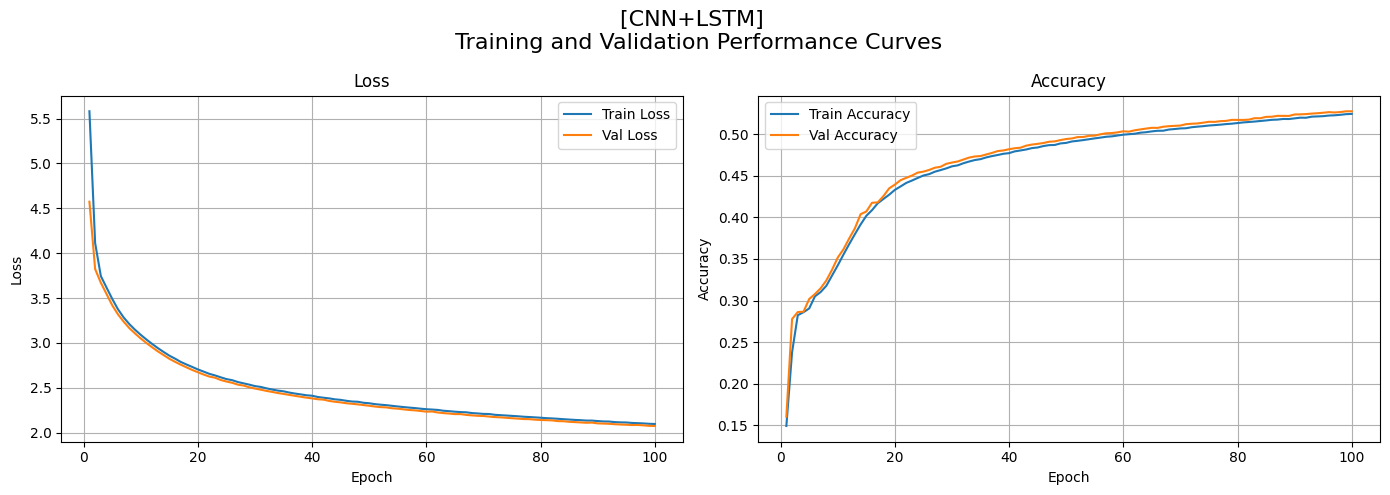

In [9]:
metrics_1 = load_metrics("/content/drive/MyDrive/Group Project 2025-2026/metrics_1.pkl")

train_losses_1 = metrics_1["train_losses"]
val_losses_1 = metrics_1["val_losses"]
train_accuracies_1 = metrics_1["train_accuracies"]
val_accuracies_1 = metrics_1["val_accuracies"]

# Model 1
plot_training_curves("CNN+LSTM",train_losses_1, val_losses_1, train_accuracies_1, val_accuracies_1)

# **Model 2: Transformer**

## ViT Encoder

In [ ]:
patch_size = 10
def extract_patches(image, patch_size):
  B, C, H, W = image.shape # Batch, Channel, Height, Width
  assert H % patch_size == 0
  assert W % patch_size == 0
  patchs = image.unfold (2,patch_size,patch_size).unfold(3,patch_size,patch_size)
  patchs = patchs.contiguous().view(B, C, -1, patch_size, patch_size)
  B_new, C_new, N, first_patch_size, second_patch_size = patchs.shape
  patchs = patchs.view(B_new ,N , -1)
  return patchs

In [ ]:
class Patch_embedding(nn.Module):
  def  __init__(self,patch_size, num_patchs, embedding_dim):
     super().__init__()
     self.patch_size = patch_size
     self.num_patches = num_patchs
     self.embedding_dim = embedding_dim
     self.patch_embed = nn.Linear(self.patch_size**2,self.embedding_dim)
     self.cls_token = nn.Parameter(torch.randn(1, 1, self.embedding_dim))
     self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, self.embedding_dim))
  def forward(self,x):
    B, N , P = x.shape
    patch_embedding = self.patch_embed(x)
    cls_tokens = self.cls_token.expand(B, -1, -1)
    tokens = torch.cat((cls_tokens, patch_embedding), dim=1)
    return tokens + self.pos_embed

In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self, embedding_dim, num_head:int=16 , dropout: float = 0) -> None:
     super().__init__()
     self.layer_norm=nn.LayerNorm(embedding_dim)
     self.mha = nn.MultiheadAttention(embed_dim=embedding_dim,
                                      num_heads=num_head,
                                      dropout=dropout,
                                      batch_first=True)
  def forward(self,x):
    x_norm = self.layer_norm(x)
    x_attention,_ = self.mha(query = x_norm,
                           key = x_norm,
                           value = x_norm,
                           need_weights = False)
    return  x + x_attention

In [ ]:
class MLP_Block(nn.Module):
  def __init__(self, embedding_dim,mlp_size: int = 4096 ,dropout: float = 0.1) :
     super().__init__()
     self.layer_norm=nn.LayerNorm(embedding_dim)
     self.mlp = nn.Sequential(nn.Linear(embedding_dim,mlp_size),
                              nn.GELU(),
                              nn.Dropout(dropout),
                              nn.Linear(mlp_size,embedding_dim),
                              nn.Dropout(dropout))
  def forward(self,x):
    x_norm = self.layer_norm(x)
    x_mlp = self.mlp(x_norm)
    return x + x_mlp

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self, embedding_dim, num_head:int=16 , attn_dropout: float = 0 , mlp_size: int =4096 , mlp_dropout: float = 0.1 ):
     super().__init__()
     self.attn = MultiheadAttention(embedding_dim,num_head,attn_dropout)
     self.mlp = MLP_Block(embedding_dim,mlp_size,mlp_dropout)
  def forward(self,x):
    x_attn = self.attn(x)
    x_mlp = self.mlp(x_attn)
    return x_mlp

In [ ]:
class TransformerEncoder(nn.Module):
  def __init__(self, embedding_dim,num_layers, num_head:int=16 , attn_dropout: float = 0 , mlp_size: int =4096 , mlp_dropout: float = 0.1):
    super().__init__()
    self.layers = nn.ModuleList([
            TransformerEncoderLayer(
                embedding_dim=embedding_dim,
                num_head=num_head,
                mlp_size=mlp_size,
                attn_dropout=attn_dropout,
                mlp_dropout=mlp_dropout
            )
            for _ in range(num_layers)
        ])
  def forward(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

In [ ]:
class ViT(nn.Module):
  def __init__(self, patch_size, num_patches, embedding_dim, num_layers):
     super().__init__()
     self.patch_size = patch_size
     self.embed = Patch_embedding(patch_size,num_patches,embedding_dim)
     self.transformer = TransformerEncoder(embedding_dim,num_layers)
  def forward(self,x):
     out1 = extract_patches(x,self.patch_size)
     out2 = self.embed(out1)
     out3 = self.transformer(out2)
     return out3

## Transformer Decoder

In [ ]:
class Sequence_Embedding(nn.Module):
  def __init__(self, max_seq_length: int, vocab_size: int, embed_dim: int):
    '''
      Class tỏch.nn.Embedding:
      num_embeddings (int) – size of the dictionary of embeddings
      embedding_dim (int) – the size of each embedding vector
    '''
    super().__init__()
    self.pos_embedding = nn.Embedding(num_embeddings = max_seq_length,
                                      embedding_dim = embed_dim)
    self.token_embedding = nn.Embedding(num_embeddings = vocab_size,
                                        embedding_dim = embed_dim)
  def forward(self, sequence: torch.tensor):
    # Input sequence's shape: (batch_size, seq_len)
    batch_size, seq_len = sequence.shape

    # Token embedding
    token_embed = self.token_embedding(sequence)         # (batch_size, seq_len, embed_dim)

    # Position embedding
    position = torch.arange(seq_len, device = sequence.device)  # (seq_len,)
    position = position.unsqueeze(0)                     # (1, seq_len)
    pos_embed = self.pos_embedding(position)             # (1, seq_len, embed_dim)

    return token_embed + pos_embed

In [ ]:
class Causal_Multihead_Attention(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
    super().__init__()
    assert embed_dim % num_heads == 0 # Make sure that embedding dim is divisable to number of heads

    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim,)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim = embed_dim,
                                                      num_heads = num_heads,
                                                      dropout = dropout,
                                                      batch_first = True,)
    self.dropout = nn.Dropout(p = dropout)
  def forward(self, x: torch.tensor, token_ids: torch.tensor, pad_id = vocab["<pad>"]):
    x_norm = self.layer_norm(x)
    max_seq_len = x.shape[1]

    # Create mask
    key_padding_mask = (token_ids == pad_id)    # shape (batch_size, tokens), dtype bool
    causal_mask = torch.triu(torch.ones(max_seq_len, max_seq_len, device=x.device), diagonal=1).bool()
    output, attn_weights = self.multi_head_attention(query = x_norm,
                                                     key = x_norm,
                                                     value = x_norm,
                                                     attn_mask = causal_mask,
                                                     key_padding_mask = key_padding_mask)
    output = self.dropout(output)
    return x + output, attn_weights

In [ ]:
class Cross_Attention(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
    super().__init__()
    assert embed_dim % num_heads == 0 # Make sure that embedding dim is divisable to number of heads

    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim = embed_dim,
                                                      num_heads = num_heads,
                                                      dropout = dropout,
                                                      batch_first = True)
    self.dropout = nn.Dropout(p = dropout)
  def forward(self, x: torch.tensor, context: torch.tensor):
    # context vector is from the ViT encoder
    x_norm = self.layer_norm(x)
    output, attn_weights = self.multi_head_attention(query = x_norm,
                                                     key = context,
                                                     value = context,
                                                     is_causal = False)
    output = self.dropout(output)
    return x + output, attn_weights

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
    super().__init__()
    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
    self.feed_forward = nn.Sequential(
        nn.Linear(in_features = embed_dim,
                  out_features = hidden_dim),
        nn.GELU(),
        nn.Dropout(p = dropout),
        nn.Linear(in_features = hidden_dim,
                  out_features = embed_dim),
        nn.Dropout(p = dropout)
    )
  def forward(self, x: torch.tensor):
    x_norm = self.layer_norm(x)
    return x + self.feed_forward(x_norm)

In [ ]:
class TransformerDecoderLayer(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, ffw_dim: int, max_seq_len, vocab_size, dropout: float = 0.1):
    super().__init__()
    self.causal_attention = Causal_Multihead_Attention(embed_dim, num_heads, dropout)
    self.cross_attention = Cross_Attention(embed_dim, num_heads, dropout)
    self.feed_forward = FeedForward(embed_dim, ffw_dim, dropout)
  def forward(self, x: torch.tensor, token_ids: torch.tensor, context: torch.tensor):
    x, causal_attn_weights = self.causal_attention(x, token_ids)
    x, cross_attn_weights = self.cross_attention(x, context)
    x = self.feed_forward(x)
    return x, causal_attn_weights, cross_attn_weights

In [ ]:
class TransformerDecoder(nn.Module):
  def __init__(self, max_seq_len, vocab_size, embed_dim: int, num_layers: int, num_heads: int = 16, ffw_dim: int = 4096, dropout: float = 0.1):
    super().__init__()
    self.seq_embedding = Sequence_Embedding(max_seq_len, vocab_size, embed_dim)
    self.layers = nn.ModuleList([
        TransformerDecoderLayer(embed_dim, num_heads, ffw_dim, max_seq_len, vocab_size, dropout)
        for _ in range(num_layers)
    ])

  def forward(self, token_ids: torch.tensor, context: torch.tensor):
    causal_attn_weights = None
    cross_attn_weights = None
    x = self.seq_embedding(token_ids)
    for layer in self.layers:
      x, causal_attn_weights, cross_attn_weights = layer(x, token_ids, context)
    return x, causal_attn_weights, cross_attn_weights

## Transformer Model

In [ ]:
import torch
import torch.nn as nn

class Transformer(nn.Module):
    def __init__(self, patch_size = 10, num_patches = 100, enc_embedding_dim = 128, enc_num_layers = 12,
                 max_seq_len = max_seq_len, vocab_size = len(vocab),
                 dec_embedding_dim = 128, dec_num_layers = 12, dropout=0.1):
        super().__init__()

        # ViT Encoder
        self.encoder = ViT(
            patch_size = patch_size,
            num_patches = num_patches,
            embedding_dim = enc_embedding_dim,
            num_layers = enc_num_layers
        )

        # Transformer Decoder
        self.decoder = TransformerDecoder(
            max_seq_len = max_seq_len,
            vocab_size = vocab_size,
            embed_dim = dec_embedding_dim,
            num_layers = dec_num_layers,
            dropout = dropout
          )

        # final output projection
        self.output_projection = nn.Linear(dec_embedding_dim, vocab_size)

    def forward(self, src, tgt):
        """
        src (source): (batch_size, channel, height, width)
        tgt (target): (batch_size, max_seq_len)
        """

        enc_out = self.encoder(src)
        dec_out, causal_attn, cross_attn = self.decoder(tgt, enc_out)
        logits = self.output_projection(dec_out)  # Shape: (batch_size, max_seq_len - 1, vocab_size)

        return logits
        #return logits, causal_attn, cross_attn


## Model Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
input_shape = [c,h,w] = train_images[0].shape
embedding_dim = 128

model_2 = Transformer()

In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# Optimizer
optimizer = Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)

# Loss function (sparse categorical crossentropy)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

In [ ]:
# Save training result to plot
train_losses_2 = []
train_accuracies_2 = []
val_losses_2 = []
val_accuracies_2 = []

In [ ]:
epochs = 30
train_model(model_2, train_loader, val_loader, optimizer, criterion, vocab, train_losses_2, train_accuracies_2, val_losses_2, val_accuracies_2, epochs)

NameError: name 'train_model' is not defined

*   Model2 đầu tiên là bản fail

*   Model2official1 là bản weight_decay = 1e-5

*   Model_ViT_official là bản weight_decay = 1e-4, đầy đủ plot để giải quyết. SD bản này để làm việc

In [ ]:
torch.save(model_2.state_dict(), '/content/drive/MyDrive/Group Project 2025-2026/model_ViT_official.pth')

In [ ]:
# Save metrics to plot
save_metrics('/content/drive/MyDrive/Group Project 2025-2026/metrics_ViT_official.pkl', train_losses_2, train_accuracies_2, val_losses_2, val_accuracies_2)

In [ ]:
#This code snippet is to ensure that I can reload the model and continue to train on it
#as now I have to leave early

state = {'epoch': epochs,
         'state_dict': model_2.state_dict(),
         'optimizer': optimizer.state_dict(),
         'train_losses_2': train_losses_2,
         'train_accuracies_2': train_accuracies_2,
         'val_losses_2': val_losses_2,
         'val_accuracies_2': val_accuracies_2,
         }
filename = '/content/drive/MyDrive/Group Project 2025-2026/model_ViT_FORNEXTTRAINING.pth'
torch.save(state, filename)

#https://discuss.pytorch.org/t/loading-a-saved-model-for-continue-training/17244/4 The website I consulted

Load metrics from /content/drive/MyDrive/Group Project 2025-2026/metrics_ViT_official.pkl successfully!


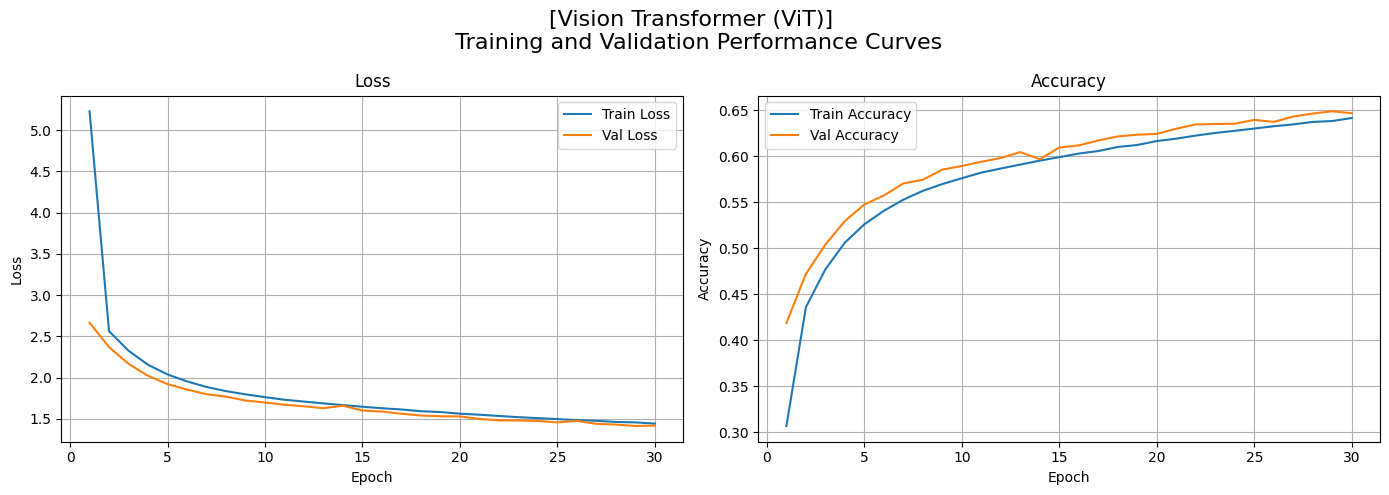

In [10]:
metrics_2 = load_metrics("/content/drive/MyDrive/Group Project 2025-2026/metrics_ViT_official.pkl")

train_losses_2 = metrics_2["train_losses"]
val_losses_2 = metrics_2["val_losses"]
train_accuracies_2 = metrics_2["train_accuracies"]
val_accuracies_2 = metrics_2["val_accuracies"]

# Model 2
plot_training_curves("Vision Transformer (ViT)", train_losses_2, val_losses_2, train_accuracies_2, val_accuracies_2)

# **Model 3: Convolutional Transformer**
NOTE: Chạy hết các cell ở model Transformer trên kia nhé :>

## Encoder

In [ ]:
class Cnn_layer(nn.Module):
  def __init__(self, input_channel, height, width, embedding_dim ,max_len = 5000 ):
    super().__init__()
    self.feature = nn.Sequential(
        #Block 1
        nn.Conv2d(input_channel, 8, kernel_size=3,stride=1, padding=1),
        nn.BatchNorm2d(8),
        nn.LeakyReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),
        #Block 2
        nn.Conv2d(8, 16, kernel_size=3,stride=1, padding=1),
        nn.BatchNorm2d(16),
        nn.LeakyReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),
        #Block 3
        nn.Conv2d(16, 32, kernel_size=3,stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),
        #Block 4
        nn.Conv2d(32, 64, kernel_size=3,stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(),

        nn.Dropout2d(0.2),
        #Block 5
        nn.Conv2d(64, 128, kernel_size=3,stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),

        nn.Dropout2d(0.2)
    )
    self.projection = nn.Linear(128, embedding_dim)
    self.pos_embed = nn.Parameter(torch.randn(1, max_len, embedding_dim))
  def forward(self,x):
  # B, C, H, W
    x = self.feature(x)
    x = torch.flatten(x, start_dim=2)
    x = x.permute(0,2,1)
    x = self.projection(x)
    seq_len = x.shape[1]
    x = x + self.pos_embed[:, :seq_len, :]

    return x

In [ ]:
class CvT(nn.Module):
  def __init__(self,  input_channel, height, width, embedding_dim, num_layer):
     super().__init__()
     self.cnn = Cnn_layer(input_channel, height, width, embedding_dim)

     self.transformer = TransformerEncoder(embedding_dim ,num_layer, num_head=4, attn_dropout=0, mlp_size=1024, mlp_dropout=0.1)
  def forward(self,x):
    out1 = self.cnn(x)
    out2 = self.transformer(out1)
    return out2

In [ ]:
class Convolutional_Transformer(nn.Module):
  def __init__(self, input_channel, height, width, enc_embedding_dim = 128, enc_num_layer = 12,
               max_seq_len = max_seq_len, vocab_size = len(vocab),
               dec_embedding_dim = 128, dec_num_layers = 12, dropout=0.1):
    super().__init__()
    self.encoder = CvT(input_channel, height, width, enc_embedding_dim, enc_num_layer)
    self.decoder = TransformerDecoder(
            max_seq_len = max_seq_len,
            vocab_size = vocab_size,
            embed_dim = dec_embedding_dim,
            num_layers = dec_num_layers,
            dropout = dropout
          )

    self.output_projection = nn.Linear(dec_embedding_dim, vocab_size)

  def forward(self, src, tgt):
    """
    src (source): (batch_size, channel, height, width)
    tgt (target): (batch_size, max_seq_len)
    """
    enc_out = self.encoder(src)
    dec_out, causal_attn, cross_attn = self.decoder(tgt, enc_out)
    logits = self.output_projection(dec_out)  # Shape: (batch_size, max_seq_len - 1, vocab_size)

    return logits

## Model Training

In [ ]:
input_shape = [c,h,w] = train_images[0].shape

model_3 = Convolutional_Transformer(input_channel = c, height = h, width = w)

In [ ]:
input_shape = [c,h,w] = train_images[0].shape
embedding_dim = 128
model_3 = Convolutional_Transformer(input_channel = c, height = h, width = w)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_3 = model_3.to(device)

# Load the saved weights
path = '/content/drive/MyDrive/Group Project 2025-2026/model_CvT_FORNEXTTRAINING.pth'
state = torch.load(path, map_location=device)
model_3.load_state_dict(state['state_dict'])
model_3.train()
print("Model loaded successfully.")

KeyboardInterrupt: 

In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# Optimizer
optimizer = Adam(model_3.parameters(), lr=5e-4, weight_decay=1e-4)

# Loss function (sparse categorical crossentropy)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
start_epoch = state['epoch'] + 1

train_losses_3 = state['train_losses_2']
train_accuracies_3 = state['train_accuracies_2']
val_losses_3 = state['val_losses_2']
val_accuracies_3 = state['val_accuracies_2']

print("Checkpoint loaded successfully.")
print(f"Resuming from epoch {start_epoch}")



In [ ]:
# Chạy được rồi con bắng chạy đi

epochs = 20
train_model(model_3, train_loader, val_loader, optimizer, criterion, vocab, train_losses_3, train_accuracies_3, val_losses_3, val_accuracies_3, epochs)

In [ ]:
torch.save(model_3.state_dict(), '/content/drive/MyDrive/Group Project 2025-2026/model_CvT_official.pth')
save_metrics('/content/drive/MyDrive/Group Project 2025-2026/metrics_CvT_official.pkl', train_losses_3, train_accuracies_3, val_losses_3, val_accuracies_3)

In [ ]:
#This code snippet is to ensure that I can reload the model and continue to train on it
#as now I have to leave early

state = {'epoch': epochs,
         'state_dict': model_3.state_dict(),
         'optimizer': optimizer.state_dict(),
         'train_losses_2': train_losses_3,
         'train_accuracies_2': train_accuracies_3,
         'val_losses_2': val_losses_3,
         'val_accuracies_2': val_accuracies_3,
         }
filename = '/content/drive/MyDrive/Group Project 2025-2026/model_CvT_FORNEXTTRAINING.pth'
torch.save(state, filename)

#https://discuss.pytorch.org/t/loading-a-saved-model-for-continue-training/17244/4 The website I consulted

Load metrics from /content/drive/MyDrive/Group Project 2025-2026/metrics_CvT_official.pkl successfully!


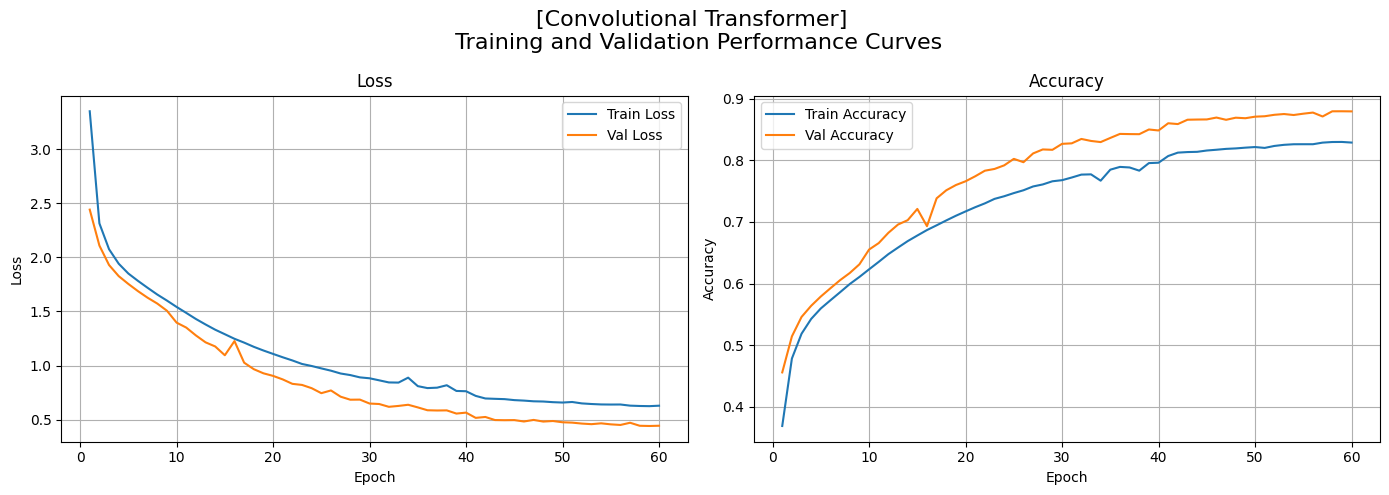

In [12]:
metrics_3 = load_metrics("/content/drive/MyDrive/Group Project 2025-2026/metrics_CvT_official.pkl")

train_losses_3 = metrics_3["train_losses"]
val_losses_3 = metrics_3["val_losses"]
train_accuracies_3 = metrics_3["train_accuracies"]
val_accuracies_3 = metrics_3["val_accuracies"]

# Model 3
plot_training_curves("Convolutional Transformer",train_losses_3, val_losses_3, train_accuracies_3, val_accuracies_3)

# **Functions for model testing**

## Decode text

In [ ]:
import torch
import torch.nn.functional as F

def beam_search(model, images, sos_id, eos_id, pad_id, max_seq_len = max_seq_len, beam_size: int = 5, length_norm = True):
  model.eval()

  batch_size = images.shape[0]

  # Reshape images (batch_size, channel, height, width)
  images = images.unsqueeze(1) # (batch_size, 1, channel, height, width)
  images = images.repeat(1, beam_size, 1, 1, 1) # (batch_size, beam_size, channel, height, width)
  images = images.view(batch_size * beam_size, *images.shape[2:]) # (batch * beam, channel, height, width)

  device = next(model.parameters()).device
  images = images.to(device)

  # Initialize beams
  seqs = torch.full((batch_size * beam_size, 1), sos_id, dtype = torch.long, device = device) #(batch * beam, 1)
  scores = torch.zeros(batch_size * beam_size, dtype = torch.float, device = device) # (batch * beam, )
  finished = torch.zeros(batch_size * beam_size, dtype = torch.bool, device = device) # (batch * beam, )

  # Mask to identify each beam belongs to which image
  beam_indices = (torch.arange(batch_size, dtype = torch.long, device = device).unsqueeze(1).repeat(1, beam_size).view(-1) * beam_size) # (batch * beam, )

  # Beam search loop
  for t in range(max_seq_len):
    logits = model(images, seqs)
    logits = logits[:,-1,:]
    ''' [Take all batch,
        take the last time step token,
        take all the vocab] '''
    log_probs = F.log_softmax(logits, dim = -1)

    # Stop expansion beams when reach <eos>
    log_probs[finished] = -1e9        # -1e9 ~ -infinity
    log_probs[finished, eos_id] = 0

    # Expand beams per image
    scores_ = scores.view(batch_size, beam_size, 1)
    log_probs = log_probs.view(batch_size, beam_size, -1)

    total_scores = scores_ + log_probs  # (batch_size, beam_size, vocab_size)

    # Select top k seq per image
    total_scores = total_scores.view(batch_size, -1)
    top_scores, top_ids = torch.topk(total_scores, k = beam_size, largest = True, dim = 1)

    vocab_size = log_probs.size(-1)

    # Which old beam was chosen
    beam_ids = top_ids // log_probs.size(-1)
    # Which new token was chosen
    token_ids = top_ids % log_probs.size(-1)

    # Convert to global indices
    beam_ids = beam_ids + beam_indices.view(batch_size, beam_size)

    beam_ids = beam_ids.view(-1)
    token_ids = token_ids.view(-1)

    # Update sequences
    seqs = torch.cat([seqs[beam_ids], token_ids.unsqueeze(1)], dim = 1)

    scores = top_scores.view(-1)
    finished = finished[beam_ids] | (token_ids == eos_id)

    # Early stopping
    if finished.view(batch_size, beam_size).all():
      break

  # Length normalization
  if length_norm:
    lengths = (seqs!= pad_id).sum(dim=1) -1
    scores = scores / lengths.clamp(min = 1)

  # Select best beam per image
  scores = scores.view(batch_size, beam_size)
  seqs = seqs.view(batch_size, beam_size, -1)

  best_ids = torch.argmax(scores, dim = 1)
  best_seqs = seqs[torch.arange(batch_size), best_ids]

  # Remove <sos> and <eos>
  result = []
  for seq in best_seqs.tolist():
    if seq[0] == sos_id:
      seq = seq[1:]
    if eos_id in seq:
      seq = seq[:seq.index(eos_id)]
    result.append(seq)

  return result

In [ ]:
def decode_text(token_ids_batch, vocab):
  """
  Decode a batch of token IDs into tokens and strings.

  Args:
        token_ids_batch: list of lists OR 1D list of token IDs
        vocab: vocabulary object with `lookup_token(id)`

  Returns:
        decoded_tokens_list: list of list of tokens
        decoded_texts: list of strings
  """
  # If single sequence, wrap it in a list
  if isinstance(token_ids_batch[0], int):
    token_ids_batch = [token_ids_batch]

  decoded_tokens = []
  decoded_texts = []

  for token_ids in token_ids_batch:
    tokens = []
    for idx in token_ids:
      try:
        token = vocab.lookup_token(idx)
        if token == '<sos>' or token == '<eos>' or token == '<pad>':
          continue
      except IndexError:
        token = '<unk>'
      tokens.append(token)

    decoded_tokens.append(tokens)
    decoded_texts.append(' '.join(tokens))

  return decoded_tokens, decoded_texts

In [ ]:
# Khum chạy

def predict_single_sequence_1(model, image, vocab, max_seq_len = max_seq_len, beam_size: int = 5):
  sos_id = vocab['<sos>']
  eos_id = vocab['<eos>']
  pad_id = vocab['<pad>']
  seq, score = beam_search(model, image, sos_id, eos_id, pad_id, max_seq_len, beam_size = 5)
  final_tokens, final_seq = decode_text(seq, vocab)
  return final_tokens, final_seq

In [ ]:
def evaluate_model(model, test_loader, vocab, max_seq_len, beam_size=5):
    model.eval()
    device = next(model.parameters()).device

    true_sequences_tokens = []
    true_sequences_latex = []
    predicted_sequences_tokens = []
    predicted_sequences_latex = []

    with torch.no_grad():
      for images, true_latex_ids in test_loader:
          images = images.to(device)

          # Decode true sequences
          true_tokens_batch, true_latex_batch = decode_text(true_latex_ids.tolist(), vocab)
          true_sequences_tokens.extend(true_tokens_batch)
          true_sequences_latex.extend(true_latex_batch)

          # Predict sequences
          pred_tokens_batch = beam_search(
                model,
                images,
                sos_id = vocab['<sos>'],
                eos_id = vocab['<eos>'],
                pad_id = vocab['<pad>'],
                max_seq_len = max_seq_len,
                beam_size = beam_size
            )

          # Decode predicted sequences
          pred_tokens_decoded, pred_latex_decoded = decode_text(pred_tokens_batch, vocab)
          predicted_sequences_tokens.extend(pred_tokens_decoded)
          predicted_sequences_latex.extend(pred_latex_decoded)

    return true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex

## Metrics

In [ ]:
import collections
import math

In [ ]:
'''
This is the Levenshtein  distance. Levenshtein  distance is used to measure the difference between two sequences. The Levenshtein distance between two words
is the minimum number of single-character edits (insertions, deletions or substitutions) required to change one word into the other
'''
def lev_distance(sequence_one, sequence_two):
    rows = len(sequence_one)
    cols = len(sequence_two)
    ##dist_tab is a table. We will do some operations on this later
    dist_tab = np.zeros((rows + 1, cols + 1), dtype=int)
    ##here we are initializing the elements inside the table first. We will soon change the numbers in some entries after this.
    for i in range(1, rows + 1):
      dist_tab[i][0] = i
    for i in range(1, cols + 1):
      dist_tab[0][i] = i
    for r in range(1, rows + 1):
      for c in range(1, cols + 1):

        #if tokens match
        if sequence_one[r - 1] == sequence_two[c - 1]:
          #if tokens match, we keep the min-cost the same
          #same cost as min cost from prev tokens
          dist_tab[r][c] = dist_tab[r - 1][c - 1]
        else:

          #min of deletion, insertion, or substitution respectively
          dist_tab[r][c] = 1 + min(dist_tab[r - 1][c], dist_tab[r][c - 1], dist_tab[r - 1][c - 1])
    return dist_tab[rows][cols] # Return the raw Levenshtein distance

In [ ]:
def compute_levenshtein_metrics(predicted, ground_truth):
    dist_list = []
    norm_list = []

    for pred, true in zip(predicted, ground_truth):
        dist = lev_distance(pred, true)   # token-level
        dist_list.append(dist)

        max_len = max(len(pred), len(true))
        norm = dist / max_len if max_len > 0 else 1
        norm_list.append(norm)

    avg_dist = np.mean(dist_list)
    avg_norm = np.mean(norm_list)
    return avg_dist, avg_norm

In [ ]:
def bleu_n_score(generated_sequence, true_sequence, n):
    gen_len = len(generated_sequence)
    true_len = len(true_sequence)
    scores = []

    if gen_len == 0:
      return 0.0

    #calculate overlap for 1-grams to n-grams
    for gram_size in range(1,n+1):

      #generate grams
      gen_ngrams = [tuple(generated_sequence[i:i+gram_size]) for i in range(gen_len - gram_size + 1)]
      true_ngrams = [tuple(true_sequence[i:i+gram_size]) for i in range(true_len - gram_size + 1)]

      gen_grams_count = collections.Counter(gen_ngrams) #freq dictionaries of grams
      true_grams_count = collections.Counter(true_ngrams)

      #sum of how many grams appear in both the gen sequence and the true
      matching_grams_sum = sum(min(gen_grams_count[gram], true_grams_count[gram]) for gram in gen_grams_count)

      #divide sum of matching grams by total number of grams in the gen sequence (precision)

      #gram_score = 0
      #if len(gen_grams_count) > 0:
      #  gram_score = matching_grams_sum / sum(gen_grams_count.values())
      #scores.append(gram_score)

      total_gen = sum(gen_grams_count.values())
      if total_gen == 0:
        gram_score = 1e-9   # smoothing for missing n-grams
      else:
        gram_score = matching_grams_sum / total_gen
      scores.append(gram_score)

    #calculate geometric mean of scores for each gram 1-n
    geo_mean = 0.0
    for gram_score in scores:
      if gram_score == 0.0:
        #return 0 early: a score of 0 zeroes out mean and thus bleu score
        return 0.0
      geo_mean += math.log(gram_score)
    geo_mean = math.exp(geo_mean/n)

    #include brevity penalty in cases where gen sequence is longer than true sequence
    if gen_len < true_len:
      return math.exp(1 - true_len / gen_len) * geo_mean
    return geo_mean #no penalty otherwise

In [ ]:
def compute_bleus(predicted, ground_truth):
  bleu_scores = []
  for pred, true in zip(predicted, ground_truth):
    bleu_score = bleu_n_score(pred, true, 4)
    bleu_scores.append(bleu_score)
  avg_bleu = np.mean(bleu_scores)
  return avg_bleu

In [ ]:
# Compute metrics
def compute_metrics(predicted_sequences_tokens, true_sequences_tokens):
  lev_dist_val, lev_norm_val = compute_levenshtein_metrics(predicted_sequences_tokens, true_sequences_tokens)
  bleu = compute_bleus(predicted_sequences_tokens, true_sequences_tokens)
  # ---------------------------------------------------------
  # PRINT METRICS
  # ---------------------------------------------------------
  print("\n===================== METRICS ====================")
  print(f"Average Levenshtein Distance : {lev_dist_val:.4f}")
  print(f"Normalized Levenshtein       : {lev_norm_val:.4f}")
  print(f"Average BLEU Score                   : {bleu:.4f}")
  print("==================================================\n")

  return lev_dist_val, lev_norm_val, bleu

In [ ]:
def save_test_result(file_name, true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex):
  '''
  File name's extension is .pkl
  Remember to include the path for file name
  (eg: '/content/drive/MyDrive/Group Project 2025-2026/result.pkl')
  '''
  test_result = {
      'true_sequences_tokens': true_sequences_tokens,
      'true_sequences_latex': true_sequences_latex,
      'predicted_sequences_tokens': predicted_sequences_tokens,
      'predicted_sequences_latex': predicted_sequences_latex
  }

  with open(file_name, 'wb') as f:
    pickle.dump(test_result, f)
  print(f"Saved test result in {file_name} successfully!")

In [ ]:
def load_test_result(file_name):
  with open(file_name, 'rb') as f:
    test_result = pickle.load(f)
  print(f"Load test result from {file_name} successfully!")
  return test_result

# **Model 2 Evaluation**

In [ ]:
# Recreate the model architecture
input_shape = [c,h,w] = train_dataset.images[0].shape
embedding_dim = 128
model = Transformer()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

# Load the saved weights
path = "/content/drive/MyDrive/Group Project 2025-2026/model_ViT_official.pth"
state_dict = torch.load(path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex = evaluate_model(model, test_loader, vocab, max_seq_len, beam_size=5)

In [ ]:
# Test on subset (HAnLE)
# true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex = evaluate_model(model, subset_loader, vocab, max_seq_len, beam_size=5)

In [ ]:
print(compute_metrics(predicted_sequences_tokens, true_sequences_tokens))


===================== METRICS ====================
Average Levenshtein Distance : 68.0562
Normalized Levenshtein       : 1.0000
Average BLEU Score                   : 0.0000

(np.float64(68.05620473201353), np.float64(1.0), np.float64(0.0))


In [ ]:
save_test_result('/content/drive/MyDrive/Group Project 2025-2026/model2token.pkl', true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex)

Saved test result in /content/drive/MyDrive/Group Project 2025-2026/model2token.pkl successfully!


In [ ]:
# Single test (might delete later)
# Bắng chạy lại k cần chạy cái này đâu

test_image, test_actual_ids = test_dataset[106]

predicted_tokens, predicted_latex = predict_single_sequence_1(model, test_image, vocab, max_seq_len, beam_size = 5)
print("Predicted LaTeX:", predicted_latex)

actual_tokens, actual_latex = decode_text(test_actual_ids, vocab)
print("Actual LaTeX: ", actual_latex)

Predicted LaTeX: \left ( \begin { a r r a y } { c c } { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } & { 0 } \ \ \end { a r r a y } \right )
Actual LaTeX:  { \frac { d \omega } { d z } } = \omega ^ { 1 - \alpha _ { 0 } } ( 1 - \omega ) ^ { 1 - \alpha _ { 1 } }


In [ ]:
true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex = evaluate_model(model, test_loader, vocab, max_seq_len, beam_size=5)

print("\nPredicted sequences (first 5):")
for i, seq in enumerate(predicted_sequences_latex[:5]):
    print(f"  {i}: {seq}")

print("\nTrue sequences (first 5):")
for i, seq in enumerate(true_sequences_latex[:5]):
    print(f"  {i}: {seq}")

KeyboardInterrupt: 

In [ ]:
result_2 = load_test_result('/content/drive/MyDrive/Group Project 2025-2026/model2token.pkl')

Load test result from /content/drive/MyDrive/Group Project 2025-2026/model2token.pkl successfully!


In [ ]:
result_2.keys()

dict_keys(['true_sequences_tokens', 'true_sequences_latex', 'predicted_sequences_tokens', 'predicted_sequences_latex'])

##Model 3 Evaluation

In [ ]:
# Recreate the model architecture
input_shape = [c,h,w] = train_dataset.images[0].shape
embedding_dim = 128
model = Convolutional_Transformer(input_channel = c, height = h, width = w)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load the saved weights
path = "/content/drive/MyDrive/Group Project 2025-2026/model_CvT_official.pth"
state_dict = torch.load(path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded successfully.")

RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex = evaluate_model(model, test_loader, vocab, max_seq_len, beam_size=5)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a CuDNNError: cuDNN error: CUDNN_STATUS_EXECUTION_FAILED
Exception raised from run_conv_plan at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:374 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::string) + 0x57 (0x7a2cbdb7a897 in /usr/local/lib/python3.12/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0xe1c861 (0x7a2c716f2861 in /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cuda.so)
frame #2: <unknown function> + 0x1095d83 (0x7a2c7196bd83 in /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cuda.so)
frame #3: <unknown function> + 0x1097c2c (0x7a2c7196dc2c in /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cuda.so)
frame #4: <unknown function> + 0x109817b (0x7a2c7196e17b in /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cuda.so)
frame #5: <unknown function> + 0x107aca2 (0x7a2c71950ca2 in /usr/local/l

RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Test on subset (HAnLE)
# true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex = evaluate_model(model, subset_loader, vocab, max_seq_len, beam_size=5)

In [ ]:
save_test_result('/content/drive/MyDrive/Group Project 2025-2026/model3token.pkl', true_sequences_tokens, true_sequences_latex, predicted_sequences_tokens, predicted_sequences_latex)

Saved test result in /content/drive/MyDrive/Group Project 2025-2026/model3token.pkl successfully!


In [ ]:
result_3 = load_test_result('/content/drive/MyDrive/Group Project 2025-2026/model3token.pkl')

Load test result from /content/drive/MyDrive/Group Project 2025-2026/model3token.pkl successfully!


In [ ]:
print(compute_metrics(predicted_sequences_tokens, true_sequences_tokens))


===================== METRICS ====================
Average Levenshtein Distance : 12.8000
Normalized Levenshtein       : 0.1898
Average BLEU Score                   : 0.6656

(np.float64(12.8), np.float64(0.18977114176940288), np.float64(0.6655953279425522))
